Final Project: Which attributes do women and men prioritize when selecting a person to go out with?
Omar Bruce
DATA101
Professor Hossein Zare

## Introduction ##

My research question is, which attributes do women and men prioritize when selecting a person with whom to go on a date? The purpose of this analysis is to determine if there are things a person can optimize or select for when evaluating romantic or sexual options. The dataset selected is from an experiment conducted by the Columbia Univeristy School of Business entitled, Gender Differences in Mate Selection: Evidence from a Speed Dating Experiment (Fisman et al). This dataset is appropriate because it asked the participants of the experiment to rate their potential matches on a number of attributes like ambition and shared values, and then had them indicate wether or not they would like to go on a date with that person. This gives a wide range of features, as well as a specific, binary target, their decision. 

There were a large number of variables included in the experiment, but I chose to focus primarily on those that were each particpants' ratings of their potential matches. These were attractiveness (attr), sincerity (sinc), intelligence (intel), fun, ambition (amb), and shared interests (shar). To these I added two more of the variables from the survey questions, including the expectation that the other person was interested (prob_o), and how much they liked the other person (like). Finally I added their overall optimism about speed dating (exphappy), how much their interest scores were correlated (int_corr), the age gap, and wether or not each speed date was on a night with many participants or a few (condtn). 

## Data & Statistical Analysis ##

For the data wrangling part of the project, a few things had to be done. First, I only imported the variables mentioned, plus gender, decision (dec), age and age of other, to calculate the age gap, and which wave of the experiment each date was in. Next, I dropped all rows with missing values, because that still left me with over 5000 rows to work with. I calculated the age gap relative to the person who's data was in each row, meaning if the other person was 10 years older, the age gap would be 10. 10 years younger, the age gap would be -10. Then I removed all of the rows from waves 6-9, because these waves used a different rating scale for the attributes, which would have thrown off the analysis. Those waves allowed participants to allocate an unlimted number of total points to their ratings, whereas the other waves limited them to 100 points to spread over the different attritbues. 

For the exploratory data analysis (EDA), I chose to create a feature correlation matrix. This image actually confirmed that the six primary attributes are the most highly correlated with the target variable, decision. It would also confirm that the variable I created, age_gap, was the lowest in correlation, thus making it appropriate to remove in the next step. 

Before running the Logistic Regression, I chose to use LASSO to reduce some of my features, if appropriate. First I used all twelve of the features I selected and ran it through LASSO. That analysis removed the variable 'like', each particpants rating of how much they liked the other person. Intuitively this made sense, because the more you like someone, the more you would want to go out with them. I chose to remove this variable and run LASSO a second time, this time instead of dropping intelligence, it dropped the age gap instead. Since I wanted to keep each participants' six ratings of their potential matches, I used this feature set moving forward. 

Since my target variable, decision, is binary, logistic regression for classification tasks was the appropriate modeling method. Since I wanted to compare women and men, it was important to run the regression twice, once on the women, and once on the men. Per the project requirements, I then re-ran the model using PCA feature reduction. I created a scree plot which indicates that 6 principal components are needed for approximately 80% explained variance. For this part I fit the model using all of the data, then transformed the men and women separately. 

## Conclusion and Future Directions ##

There were a number of interesting findings from this analysis. First, the answer to the research question is yes, men and women prioritize different things when selecting with whom to go on a date. From the baseline logistic regression we can see that while men and women both value attractiveness, men value it a lot more. We can also see that women value intelligence more, with the men actually having an overall negative view of intelligence. From the original research it turns out that men value a woman's intelligence in comparison to his own, not her absolute intelligence (Fisman et al). We can also conclude that women are more affected by their overall optimism and expectations for dating than men are. 

For the PCA portion, it was interesting that PC1 turned out to mostly capture the six primary attributes I wanted to evaluate, while PC2-PC6 covered varying aspects of the other five features. It was also interesting to me that the scree plot for this data doesn't have a clear elbow, which means there isn't a subset of a few variable driving all of the variance. When comparing the baseline and PCA models using AOC-ROC, it becomes clear that the baseline model has more explanatory power than the PCA. This means that important data was lost when reducing the featur set down to six. This is another indication that peoples' decision on whom to date was based on a large number of factors, not just a few. 

There are many future directions I can think of for this data. The first is, how does what people say they want correspond with who they actually choose? Second, there were so many other variables I could have used, were any of those significant predictors? I didn't consider financial factors, for example, or racial. This data was so feature rich, there are many other questions I could have asked an answered. 


Works Cited

Fisman, Raymond, et al. "Gender Differences in Mate Selection: Evidence from a Speed Dating Experiment." The Quarterly Journal of Economics, vol. 121, no. 2, May 2006, pp. 673–97, https://business.columbia.edu/sites/default/files-efs/pubfiles/867/fisman%20iyengar.pdf


In [2]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LassoCV
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import roc_curve, roc_auc_score, accuracy_score, roc_auc_score
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [3]:
df_all = pd.read_csv('Speed Dating.csv', encoding='cp1252')
#csv wasn't loading properly, encoding fixed this. 

In [4]:
#Data Wrangling

df = []
df = df_all[['gender','dec','attr','sinc','intel','fun','amb','shar', 'age','age_o', 'int_corr','prob_o','like','condtn','exphappy','wave']]


df = df.dropna()


#calculate age gap in a new column. Calculated to keep negative values to show the other person is younger. 
df['age_gap'] = df['age_o'] - df['age']

#dropping rows from waves 6-9, these waves used a different rating scale for the attributes. 
df = df[~df['wave'].isin([6,7,8,9])].reset_index(drop=True)
#print(df['wave'].unique())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5444 entries, 0 to 5443
Data columns (total 17 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   gender    5444 non-null   int64  
 1   dec       5444 non-null   int64  
 2   attr      5444 non-null   float64
 3   sinc      5444 non-null   float64
 4   intel     5444 non-null   float64
 5   fun       5444 non-null   float64
 6   amb       5444 non-null   float64
 7   shar      5444 non-null   float64
 8   age       5444 non-null   float64
 9   age_o     5444 non-null   float64
 10  int_corr  5444 non-null   float64
 11  prob_o    5444 non-null   float64
 12  like      5444 non-null   float64
 13  condtn    5444 non-null   int64  
 14  exphappy  5444 non-null   float64
 15  wave      5444 non-null   int64  
 16  age_gap   5444 non-null   float64
dtypes: float64(13), int64(4)
memory usage: 723.2 KB


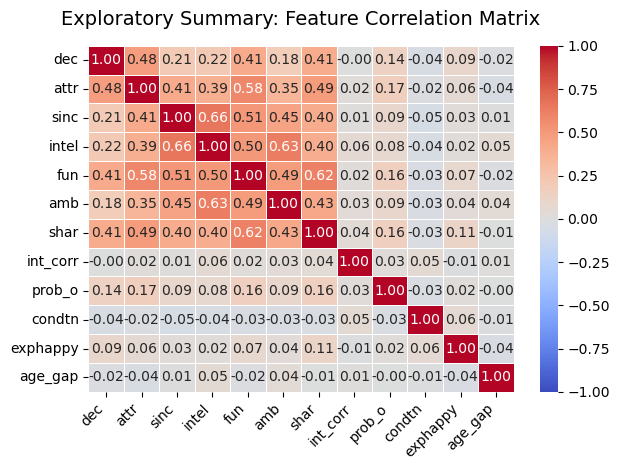

In [11]:
#EDA and visualization - Correlation Heatmap

summary_features = ['dec', 'attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'int_corr', 'prob_o', 'condtn', 'exphappy', 'age_gap']
corr_matrix = df[summary_features].corr()

sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    fmt=".2f", 
    linewidths=0.5,
    vmin=-1, 
    vmax=1
)

plt.title('Exploratory Summary: Feature Correlation Matrix', fontsize=14, pad=15)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [5]:
# Scale data 

features = df.drop(columns=['dec','gender','wave','age','age_o']).columns.tolist()
scaler = StandardScaler()
df_scaled = pd.DataFrame(scaler.fit_transform(df[features]), columns=features)

In [6]:
#Run LASSO with all eleven features. 
#Column 'like' was removed after first pass of LASSO.

lasso_features = df_scaled[['attr','sinc','intel','fun','amb','shar','int_corr','prob_o','condtn','exphappy','age_gap']]
lasso = LassoCV(cv=5, random_state=42).fit(lasso_features, df['dec'])

lasso_results = dict(zip(lasso_features, lasso.coef_))
kept_features = [feature for feature, coef in lasso_results.items() if coef != 0]

print("Features to keep:")
print(kept_features)

#dropped feature was age_gap 

Features to keep:
['attr', 'sinc', 'intel', 'fun', 'amb', 'shar', 'int_corr', 'prob_o', 'condtn', 'exphappy']


In [9]:
# Run Logistic Regression to create baseline

features_final = ['attr','sinc','intel','fun','amb','shar','int_corr','prob_o','condtn','exphappy']
df = df.reset_index(drop=True)
df_scaled = df_scaled.reset_index(drop=True)

#split data into women and men. 

female = df['gender'] == 0
male = df['gender'] == 1

X_female = df_scaled.loc[female, features_final]
y_female = df.loc[female, 'dec']

X_male = df_scaled.loc[male, features_final]
y_male = df.loc[male, 'dec']

baseline_female = LogisticRegression().fit(X_female, y_female)
baseline_male = LogisticRegression().fit(X_male, y_male)

#Output to confirm Logistic Regression was completed. 
print(f"Baseline complete: {X_female.shape[0]:,} female rows processed.")
print(f"Baseline complete: {X_male.shape[0]:,} male rows processed.")





Baseline setup complete: 2,698 female rows processed.
Baseline setup complete: 2,746 male rows processed.


In [38]:
# Create a summary table to compare the weights directly
coef_comparison = pd.DataFrame({
    'Feature': features_final,
    'Women_Coef': baseline_female.coef_[0],
    'Men_Coef': baseline_male.coef_[0]
})

# Add a column for the difference to see the age gap
coef_comparison['Gap'] = coef_comparison['Men_Coef'] - coef_comparison['Women_Coef']

#sort by absolute value of the gap
sorted_comparison = coef_comparison.sort_values(
    by='Gap', 
    key=lambda x: x.abs(), 
    ascending=False
)
print(sorted_comparison)



     Feature  Women_Coef  Men_Coef       Gap
0       attr    0.795708  1.303503  0.507795
2      intel    0.252382 -0.090979 -0.343361
9   exphappy    0.203833 -0.044516 -0.248349
8     condtn   -0.142456 -0.003981  0.138474
7     prob_o    0.157241  0.035244 -0.121997
4        amb   -0.351731 -0.277933  0.073797
3        fun    0.547580  0.510022 -0.037558
1       sinc   -0.215423 -0.243610 -0.028187
6   int_corr   -0.026308 -0.036656 -0.010348
10   age_gap    0.023710  0.033372  0.009662
5       shar    0.600390  0.591055 -0.009335


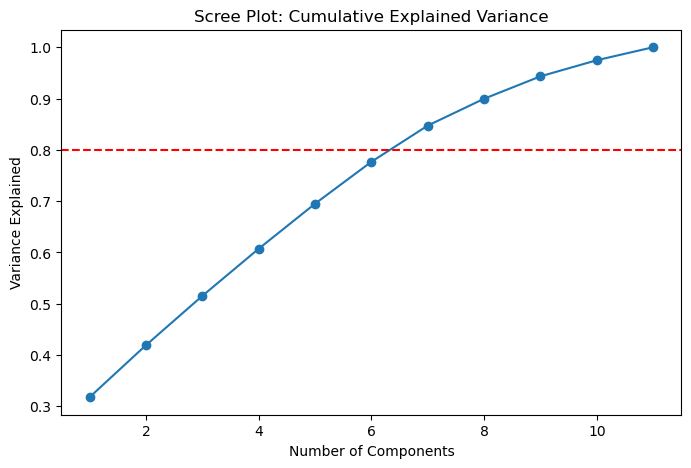

In [33]:
#Generate Scree Plot to determine how many principal components to use. 

# Fit PCA with final scaled features.

pca = PCA()
pca.fit(df_scaled[features_final])

# Generate Scree Plot

plt.figure(figsize=(8, 5))
exp_var_ratio = pca.explained_variance_ratio_
plt.plot(range(1, len(exp_var_ratio) + 1), np.cumsum(exp_var_ratio), marker='o')

plt.title('Scree Plot: Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Variance Explained')
plt.axhline(y=0.80, color='r', linestyle='--') 
plt.show()

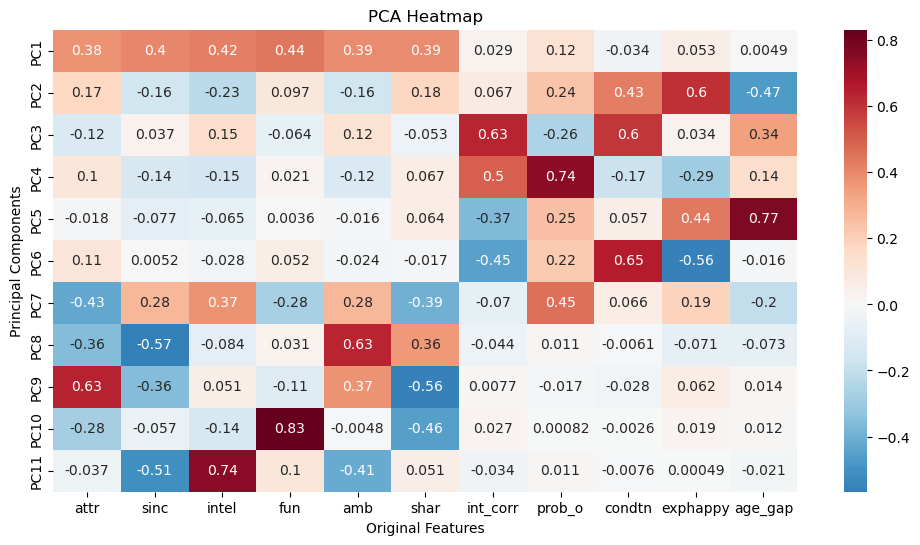

In [34]:
# Produce Heatmat of all 11 components.

X = df[features_final]
y = df['dec']

loadings = pd.DataFrame(
    pca.components_, 
    columns=X.columns, 
    index=[f'PC{i+1}' for i in range(len(pca.components_))]
)

plt.figure(figsize=(12, 6))
sns.heatmap(loadings, annot=True, cmap='RdBu_r', center=0)
plt.title('PCA Heatmap')
plt.xlabel('Original Features')
plt.ylabel('Principal Components')
plt.show()

In [50]:
# Run PCA for women and men with 6 components (80% explained variance). 

#Fit PCA on entire dataset
pca_final = PCA(n_components=6)
pca_final.fit(df_scaled[features_final])

#Transform male and female data separately 
X_female_pca = pca_final.transform(X_female)
X_male_pca = pca_final.transform(X_male)


#Re-Run Logistic Regression on PCA transformed data for men and women
model_female_pca = LogisticRegression().fit(X_female_pca, y_female)
model_male_pca = LogisticRegression().fit(X_male_pca, y_male)

# 4. Evaluate and Compare Accuracy 
def evaluate_model(model, X, y, label):
    y_pred = model.predict(X)
    acc = accuracy_score(y, y_pred)
    auc = roc_auc_score(y, model.predict_proba(X)[:, 1])
    print(f"--- {label} Performance ---")
    print(f"Accuracy: {acc:.3f}")
    print(f"AUC-ROC:  {auc:.3f}\n")

# Baseline Results
evaluate_model(baseline_female, X_female, y_female, "Women (Baseline)")
evaluate_model(baseline_male, X_male, y_male, "Men (Baseline)")

# PCA Results
evaluate_model(model_female_pca, X_female_pca, y_female, "Women (PCA - 6 Components)")
evaluate_model(model_male_pca, X_male_pca, y_male, "Men (PCA - 6 Components)")





--- Women (Baseline) Performance ---
Accuracy: 0.750
AUC-ROC:  0.825

--- Men (Baseline) Performance ---
Accuracy: 0.755
AUC-ROC:  0.832

--- Women (PCA - 6 Components) Performance ---
Accuracy: 0.723
AUC-ROC:  0.789

--- Men (PCA - 6 Components) Performance ---
Accuracy: 0.710
AUC-ROC:  0.771



In [43]:
# Create a summary table for the PCA-based models
pca_coef_comparison = pd.DataFrame({
    'Component': [f'PC{i+1}' for i in range(6)],
    'Women_PCA_Coef': model_female_pca.coef_[0],
    'Men_PCA_Coef': model_male_pca.coef_[0]
})

# Calculate the Gap for the components
pca_coef_comparison['Gap'] = pca_coef_comparison['Men_PCA_Coef'] - pca_coef_comparison['Women_PCA_Coef']

# print("PCA Model Coefficient Comparison:")
# print(pca_coef_comparison.sort_values(by='Gap', ascending=False))

# 1. Add a column for the absolute value of the gap
pca_coef_comparison['Abs_Gap'] = pca_coef_comparison['Gap'].abs()

# 2. Sort the table by the absolute gap column in descending order
sorted_pca_comparison = pca_coef_comparison.sort_values(by='Abs_Gap', ascending=False)

print("PCA Model Coefficient Comparison:")
print(sorted_pca_comparison.drop(columns=['Abs_Gap']))


PCA Model Coefficient Comparison:
  Component  Women_PCA_Coef  Men_PCA_Coef       Gap
1       PC2        0.502002     -0.105966 -0.607968
3       PC4        0.338805     -0.068045 -0.406850
4       PC5       -0.135501      0.115332  0.250833
0       PC1        0.644696      0.585178 -0.059518
2       PC3       -0.237405     -0.282415 -0.045010
5       PC6        0.017445      0.037560  0.020115


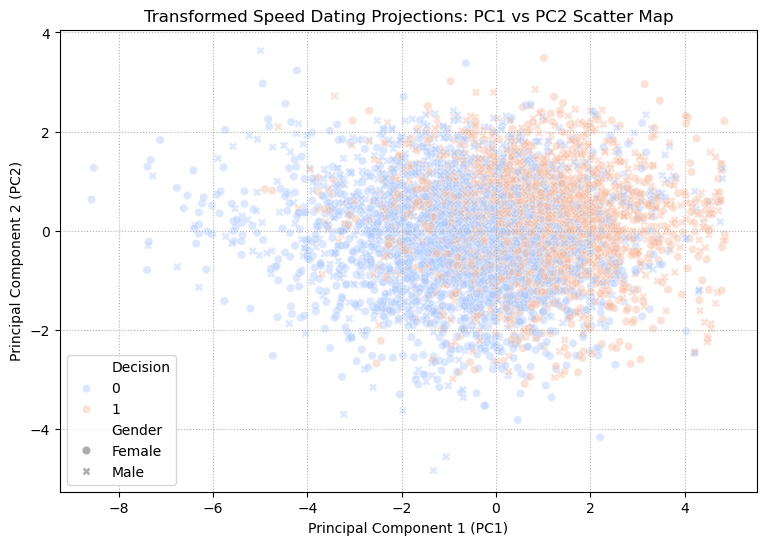

In [52]:
#PC1 vs PC2 Visualization 

pca_transformed_all = pca_final.transform(df_scaled[features_final])

df_pca = pd.DataFrame({
    'PC1': pca_transformed_all[:, 0],
    'PC2': pca_transformed_all[:, 1],
    'Decision': df['dec'],
    'Gender': df['gender'].map({0: 'Female', 1: 'Male'})
})


plt.figure(figsize=(9, 6))
sns.scatterplot(data=df_pca, x='PC1', y='PC2', hue='Decision', style='Gender', alpha=0.4, palette='coolwarm')
plt.title('Transformed Speed Dating Projections: PC1 vs PC2 Scatter Map')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle=':')
plt.show()